<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

Resolución punto por punto del paso 4

Se importan las bases más importantes que vamos a utilizar: Pandas y Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Se cargan los datos de las dos bases de datos que nos dan en el punto 4: el nombre de las compañías y la cantidad de número de viajes de cada una.

In [2]:
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_locations = pd.read_csv('/datasets/project_sql_result_04.csv')

Se sacan las 10 primeras filas de barrios por finalización de recorridos, al igual que las 10 primeras filas de la cantidad de viajes de cada compañía de taxis.

In [3]:
print("Datos de compañías de taxi:")
display(df_companies.head(10))

print("\nDatos de barrios por finalización de viajes:")
display(df_locations.head(10))

Datos de compañías de taxi:


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953



Datos de barrios por finalización de viajes:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [4]:
# Verificamos los tipos de datos de cada columna
print("Tipos de datos - df_companies:")
print(df_companies.dtypes)

print("\nTipos de datos - df_locations:")
print(df_locations.dtypes)


Tipos de datos - df_companies:
company_name    object
trips_amount     int64
dtype: object

Tipos de datos - df_locations:
dropoff_location_name     object
average_trips            float64
dtype: object


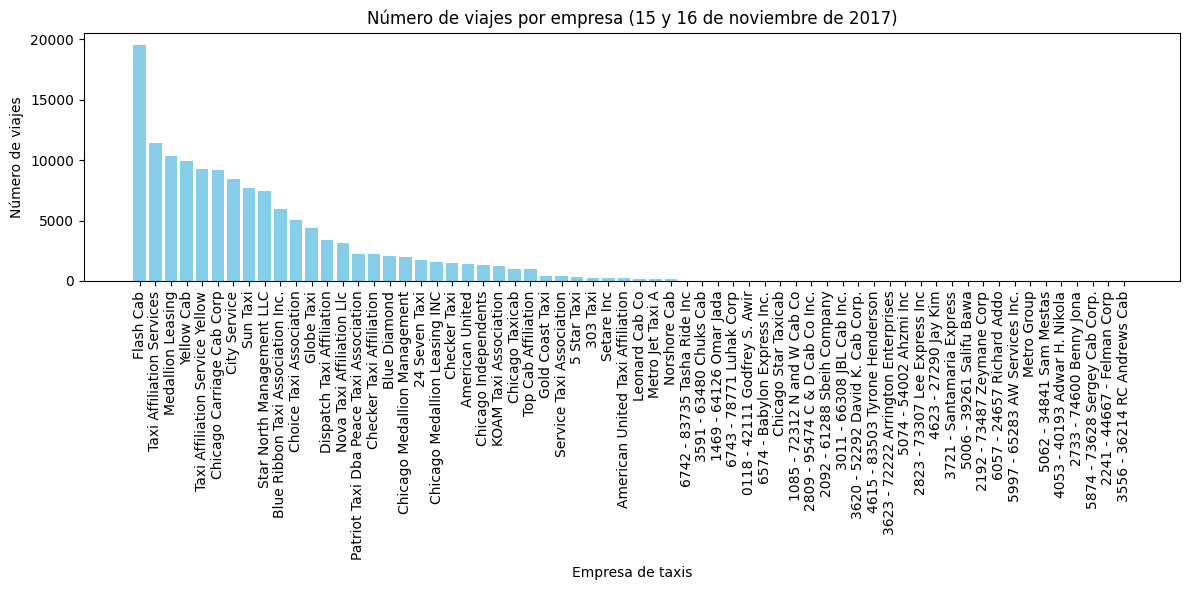

In [5]:
# Creamos un gráfico de barras con el número de viajes por empresa
plt.figure(figsize=(12, 6))
plt.bar(df_companies['company_name'], df_companies['trips_amount'], color='skyblue')
plt.xticks(rotation=90)
plt.title('Número de viajes por empresa (15 y 16 de noviembre de 2017)')
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de mostrar el resultado, se puede observar la compañía que tiene más viajes agendados
</div>

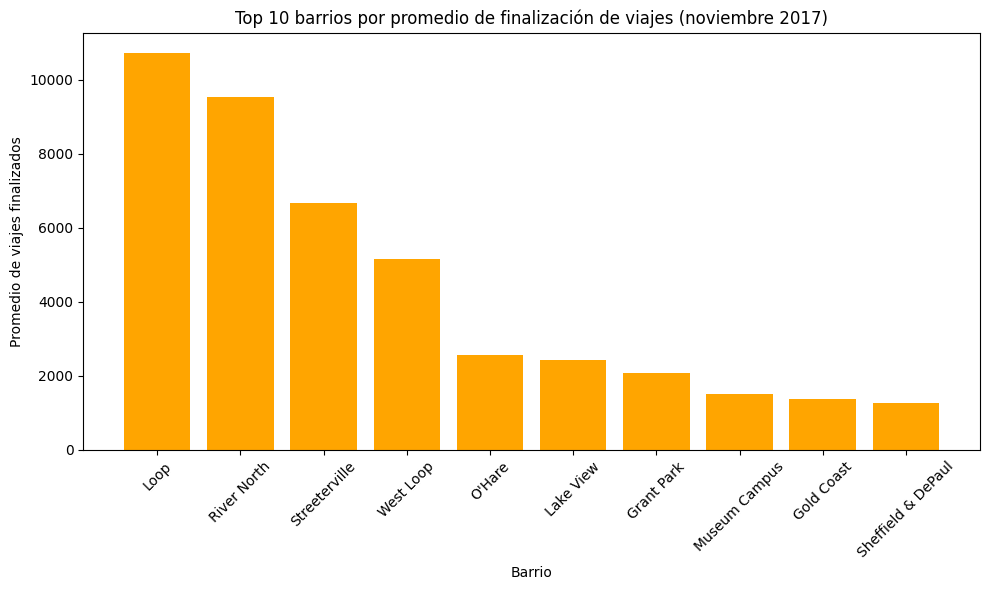

In [6]:
# Ordenamos los barrios y seleccionamos los 10 principales
top10_locations = df_locations.sort_values(by='average_trips', ascending=False).head(10)

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top10_locations['dropoff_location_name'], top10_locations['average_trips'], color='orange')
plt.title('Top 10 barrios por promedio de finalización de viajes (noviembre 2017)')
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes finalizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de crear una grafica que nos muestra los lugares más frecuentados
</div>

  Conclusiones del Paso 4

1. Las empresas con más viajes el 15 y 16 de noviembre fueron "Flash Cab", "Taxi Affiliation Services" y ""Medallion Leasin".
2. Estas son las empresas que más parecen tener una posición fuerte en el mercado de taxis en Chicago como lo demuesra la gráfica.
3. Los barrios con más viajes finalizados en noviembre fueron "Loop", "River North" y "Streeterville".
4. Estos barrios probablemente tienen mucha actividad comercial, turística o de transporte.
5. Esta información nos permite ayudar a Zuber a identificar zonas de alta demanda y principales competidores y crear nuevas estrategias de mercadeo y publicidad.


Resolución punto por punto del paso 5

In [7]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Cargamos el archivo de viajes Loop → O'Hare con clima
df_trips = pd.read_csv('/datasets/project_sql_result_07.csv')
df_trips.head(10)

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0


In [9]:
print(df_trips.dtypes)
print("\nValores en 'weather_conditions':", df_trips['weather_conditions'].unique())

start_ts               object
weather_conditions     object
duration_seconds      float64
dtype: object

Valores en 'weather_conditions': ['Good' 'Bad']


In [10]:
# Eliminamos valores nulos (por seguridad)
df_trips = df_trips.dropna(subset=['weather_conditions', 'duration_seconds'])

# Separamos los datos en dos grupos según el clima
good_weather = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<b/>

La manera de separar la información de ambos días es correcta
</div>

In [11]:
print("Viajes con buen clima:", len(good_weather))
print("Viajes con mal clima:", len(bad_weather))

Viajes con buen clima: 888
Viajes con mal clima: 180


Gráficos comprativos

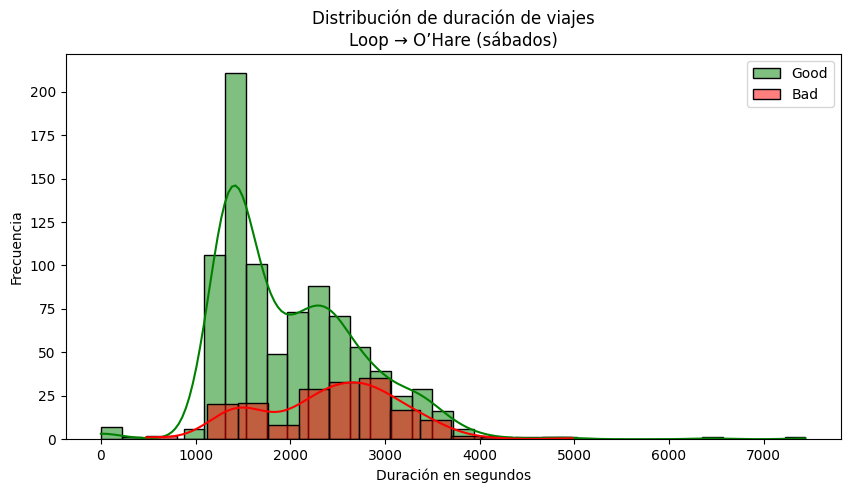

In [12]:
# Histograma comparativo
plt.figure(figsize=(10, 5))
sns.histplot(good_weather, label='Good', color='green', kde=True)
sns.histplot(bad_weather, label='Bad', color='red', kde=True)
plt.legend()
plt.title('Distribución de duración de viajes\nLoop → O’Hare (sábados)')
plt.xlabel('Duración en segundos')
plt.ylabel('Frecuencia')
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<b/>

Podemos ver que las distribuciones de ambos días difieren
</div>

Estadísticas descriptivas

In [13]:
# Promedios y tamaños de muestra
print("Duración promedio - Good:", round(good_weather.mean(), 2), "segundos")
print("Duración promedio - Bad :", round(bad_weather.mean(), 2), "segundos")
print("\nTamaño de muestra Good:", len(good_weather))
print("Tamaño de muestra Bad :", len(bad_weather))


Duración promedio - Good: 1999.68 segundos
Duración promedio - Bad : 2427.21 segundos

Tamaño de muestra Good: 888
Tamaño de muestra Bad : 180


Prueba de hipótesis (t-test)

In [14]:
# Nivel de significación
alpha = 0.05

# Prueba t de Student
results = ttest_ind(good_weather, bad_weather, equal_var=False)  # Welch's t-test

print("Estadístico t:", results.statistic)
print("p-valor:", results.pvalue)

# Interpretación
if results.pvalue < alpha:
    print("\nRechazamos la hipótesis nula: Hay diferencia significativa.")
else:
    print("\nNo se puede rechazar la hipótesis nula: No hay diferencia significativa.")


Estadístico t: -7.186034288068629
p-valor: 6.738994326108734e-12

Rechazamos la hipótesis nula: Hay diferencia significativa.


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<br/>

Es correcto rechazar la hipotesis nula, debido a que sí hay notables cambios entre un día de buenas condiciones y uno con malas condiciones
</div>

Conclusión

Prueba de hipótesis: ¿Cambia la duración de los viajes los sábados lluviosos?

1. Hipótesis nula (H₀): La duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare es la misma los sábados con buen clima y con mal clima.

2. Hipótesis alternativa (H₁): La duración promedio de los viajes es diferente los sábados con mal clima.

3. Nivel de significación (α): 0.05

4. Resultados de la prueba:
- Estadístico t: -7.18
- p-valor: 6.738994326108734e-12

Conclusión:
Podemos concluir que rechazamos la hipótesis nula porque el p-valor es mucho menor que 0.05.  
Esto significa que hay una diferencia significativa en la duración promedio de los viajes entre sábados con buen clima y con mal clima.

Este resultado puede indicar que el clima lluvioso o tormentoso afecta negativamente el tiempo de viaje, posiblemente debido al tráfico, precauciones en la conducción o condiciones de la vía.

Zuber puede tenerlo en cuenta para ajustar tiempos estimados de viaje o análisis de eficiencia en días de mal clima.


# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar las hipotesis con procesos estadisticos.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado y limpio
    
</div>
